# Process AIT Log Data Set v2.0

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## Load Data

In [41]:
# santos
scenario = "santos"

sim_start = pd.Timestamp("2022-01-14 00:00")
sim_end   = pd.Timestamp("2022-01-18 00:00")

attack_start = pd.Timestamp("2022-01-17 11:15")
attack_end   = pd.Timestamp("2022-01-17 11:59")

In [42]:
# # # fox
# scenario = "fox"

# sim_start = pd.Timestamp("2022-01-15 00:00")
# sim_end   = pd.Timestamp("2022-01-20 00:00")

# attack_start = pd.Timestamp("2022-01-18 11:59")
# attack_end   = pd.Timestamp("2022-01-18 13:15")

In [43]:
dataset = "aitv2"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"
df_all_sensors = pd.read_csv(f"{data_dir}/all_flows_labeled_unprocessed.csv")

## Trim to Simulation Period

In [44]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-13 13:20:45.726470947 to 2022-01-18 05:41:41.618597031
Total flows in combined dataset: 599243


In [45]:
# Trim to simulation period
df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]
print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-14 00:00:00 to 2022-01-18 00:00:00
Total flows in simulation period: 559329


## Remove Duplicate Rows

### Load Netflow Data

In [46]:
netflows_path = f"../data/raw/{dataset}/{scenario}/netflows/all_netflows.csv"

df_netflows = pd.read_csv(netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
netflows_labels = df_netflows["label"].unique()

print(netflows_labels)
print(df_netflows_labels_counts)
print()

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP' 'HTTP(S) intra'
 'HTTPS' 'host_discover_local' 'dirb_scan' 'wpscan' 'upload_rce_shell'
 'list_www' 'check_user_id' 'check_id' 'check_netstat_nat' 'check_whoami'
 'check_date' 'check_meminfo' 'check_netstat_l' 'check_who' 'check_pwd'
 'clear' 'check_network_config' 'list_l' 'check_uname_r' 'check_ps_a'
 'read_resolv' 'check_last' 'check_uptime' 'read_passwd' 'check_release'
 'check_netstat_t' 'check_df' 'list_web_dir' 'check_uname_a' 'list_home'
 'read_group' 'check_wp_config' 'dump_wp_users' 'dns_brute_force_start'
 'HTTP(S) DMZ' 'broken flow - benign' 'data exfiltration' 'NTP' 'mDNSv6'
 'mDNS' 'bootp' 'systemd-resolver (local)'
 'benign DNS - attacker requesting updates' 'benign DNS' 'QUIC' 'OpenVPN'
 'STUN VoIP' 'NetBIOS']
label
proxy              84132
benign DNS         70915
HTTP(S) DMZ        38200
browsing/upd

### Check Labeling

In [47]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [48]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
missing_labels = [label for label in netflows_labels if label not in observed_labels]
print(missing_labels)

Unique labels observed across all sensors:
['list_www', 'bootp', 'check_uname_r', 'host_discover_dmz', 'check_last', 'browsing/update', 'read_group', 'check_id', 'NTP', 'list_web_dir', 'HTTP(S) DMZ', 'online_cracking', 'benign DNS', 'check_ps_a', 'systemd-resolver (local)', 'check_release', 'QUIC', 'broken flow - benign', 'check_pwd', 'dirb_scan', 'HTTPS', 'mail', 'check_netstat_l', 'upload_rce_shell', 'benign_share', 'check_uname_a', 'check_netstat_nat', 'check_wp_config', 'dump_wp_users', 'service_scan', 'dns_brute_force_start', 'monitoring', 'check_user_id', 'proxy', 'OpenVPN', 'SSH', 'list_home', 'check_whoami', 'read_passwd', 'check_network_config', 'DNS', 'benign DNS - attacker requesting updates', 'data exfiltration', 'check_netstat_t', 'wpscan', 'check_who', 'HTTP', 'check_date', 'list_l', 'host_discover_local', 'STUN VoIP', 'clear', 'check_uptime', 'read_resolv', 'check_df', 'update/command on unassigned port', 'HTTP(S) intra', 'check_meminfo', 'benign']
Labels in netflows but

In [49]:
for label in observed_labels:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'list_www': 4
Number of flows with label 'list_www' in netflows: 2

Observed number of flows with label 'bootp': 141
Number of flows with label 'bootp' in netflows: 802

Observed number of flows with label 'check_uname_r': 4
Number of flows with label 'check_uname_r' in netflows: 2

Observed number of flows with label 'host_discover_dmz': 223
Number of flows with label 'host_discover_dmz' in netflows: 115

Observed number of flows with label 'check_last': 4
Number of flows with label 'check_last' in netflows: 2

Observed number of flows with label 'browsing/update': 36083
Number of flows with label 'browsing/update' in netflows: 29515

Observed number of flows with label 'read_group': 4
Number of flows with label 'read_group' in netflows: 2

Observed number of flows with label 'check_id': 4
Number of flows with label 'check_id' in netflows: 2

Observed number of flows with label 'NTP': 7327
Number of flows with label 'NTP' in netflows: 7122

Observed

In [50]:
label = "data exfiltration"
print("Data exfiltration label counts:")
print(f"Observed: {observed_labels_counts.get(label, 0)}")
print(f"Netflows: {df_netflows_labels_counts.get(label, 0)}")

Data exfiltration label counts:
Observed: 38548
Netflows: 12848


### Remove Duplicates

In [51]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_hash", "end_hash"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (559329, 30)
Final dataset shape: (352749, 27)


In [52]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'list_www': 2
Number of flows with label 'list_www' in netflows: 2

Observed number of flows with label 'bootp': 124
Number of flows with label 'bootp' in netflows: 802

Observed number of flows with label 'check_uname_r': 2
Number of flows with label 'check_uname_r' in netflows: 2

Observed number of flows with label 'host_discover_dmz': 115
Number of flows with label 'host_discover_dmz' in netflows: 115

Observed number of flows with label 'check_last': 2
Number of flows with label 'check_last' in netflows: 2

Observed number of flows with label 'browsing/update': 29613
Number of flows with label 'browsing/update' in netflows: 29515

Observed number of flows with label 'read_group': 2
Number of flows with label 'read_group' in netflows: 2

Observed number of flows with label 'check_id': 2
Number of flows with label 'check_id' in netflows: 2

Observed number of flows with label 'NTP': 7033
Number of flows with label 'NTP' in netflows: 7122

Observed

### Save Final Dataset

In [53]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_flows_labeled_sim.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (352749, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
36778,f1115,1.642118e+09,1.642118e+09,0.021806,172.21.128.54,55156,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-14 00:00:02.425734043,2022-01-14 00:00:02.447540045
36780,f3100,1.642118e+09,1.642118e+09,0.019958,172.21.128.54,55156,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-14 00:00:02.427603960,2022-01-14 00:00:02.447561979
36782,f1116,1.642118e+09,1.642118e+09,0.011838,172.21.128.54,55158,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-14 00:00:02.512283087,2022-01-14 00:00:02.524121046
36784,f3101,1.642118e+09,1.642118e+09,0.010949,172.21.128.54,55158,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-14 00:00:02.513200997,2022-01-14 00:00:02.524149895
36786,f3102,1.642118e+09,1.642118e+09,0.005656,192.168.104.218,35467,192.168.104.1,53,udp,dns,...,1,296,1,312,-,17,benign DNS,internal_share,2022-01-14 00:00:09.728241920,2022-01-14 00:00:09.733897924


## Plotting

In [54]:
# From now on only use df
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [55]:
def plot_event_raster(df_attack, order, attack=False, invert_y=True, save_plot=False, file_path=None):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title("Multi-Step Attack Scenario", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    if save_plot:
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()

### Plot Full Simulation Period

In [56]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'DNS', 'update/command on unassigned port', 'monitoring', 'HTTP', 'HTTP(S) intra', 'HTTPS', 'host_discover_local', 'dirb_scan', 'wpscan', 'upload_rce_shell', 'list_www', 'check_user_id', 'check_id', 'check_netstat_nat', 'check_whoami', 'check_date', 'check_meminfo', 'check_netstat_l', 'check_who', 'check_pwd', 'clear', 'check_network_config', 'list_l', 'check_uname_r', 'check_ps_a', 'read_resolv', 'check_last', 'check_uptime', 'read_passwd', 'check_release', 'check_netstat_t', 'check_df', 'list_web_dir', 'check_uname_a', 'list_home', 'read_group', 'check_wp_config', 'dump_wp_users', 'dns_brute_force_start', 'HTTP(S) DMZ', 'broken flow - benign', 'data exfiltration', 'NTP', 'mDNSv6', 'mDNS', 'bootp', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'benign DNS', 'QUIC', 'OpenVPN', 'STUN VoIP', 'NetBIOS', 'benign']


In [57]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
benign_share,2022-01-14 00:00:02.425734043,2022-01-17 23:45:02.306144953
benign DNS,2022-01-14 00:00:09.728241920,2022-01-17 23:58:37.136760950
data exfiltration,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
benign,2022-01-14 00:00:23.517299890,2022-01-17 23:59:07.776370049
browsing/update,2022-01-14 00:00:23.922441006,2022-01-17 23:44:37.067908049
NTP,2022-01-14 00:00:58.747752905,2022-01-17 23:59:53.819441080
monitoring,2022-01-14 00:09:05.722054005,2022-01-17 23:39:05.678922892
broken flow - benign,2022-01-14 04:22:55.214932919,2022-01-17 23:09:07.756174088
systemd-resolver (local),2022-01-14 05:14:57.174271107,2022-01-17 11:58:57.583493948


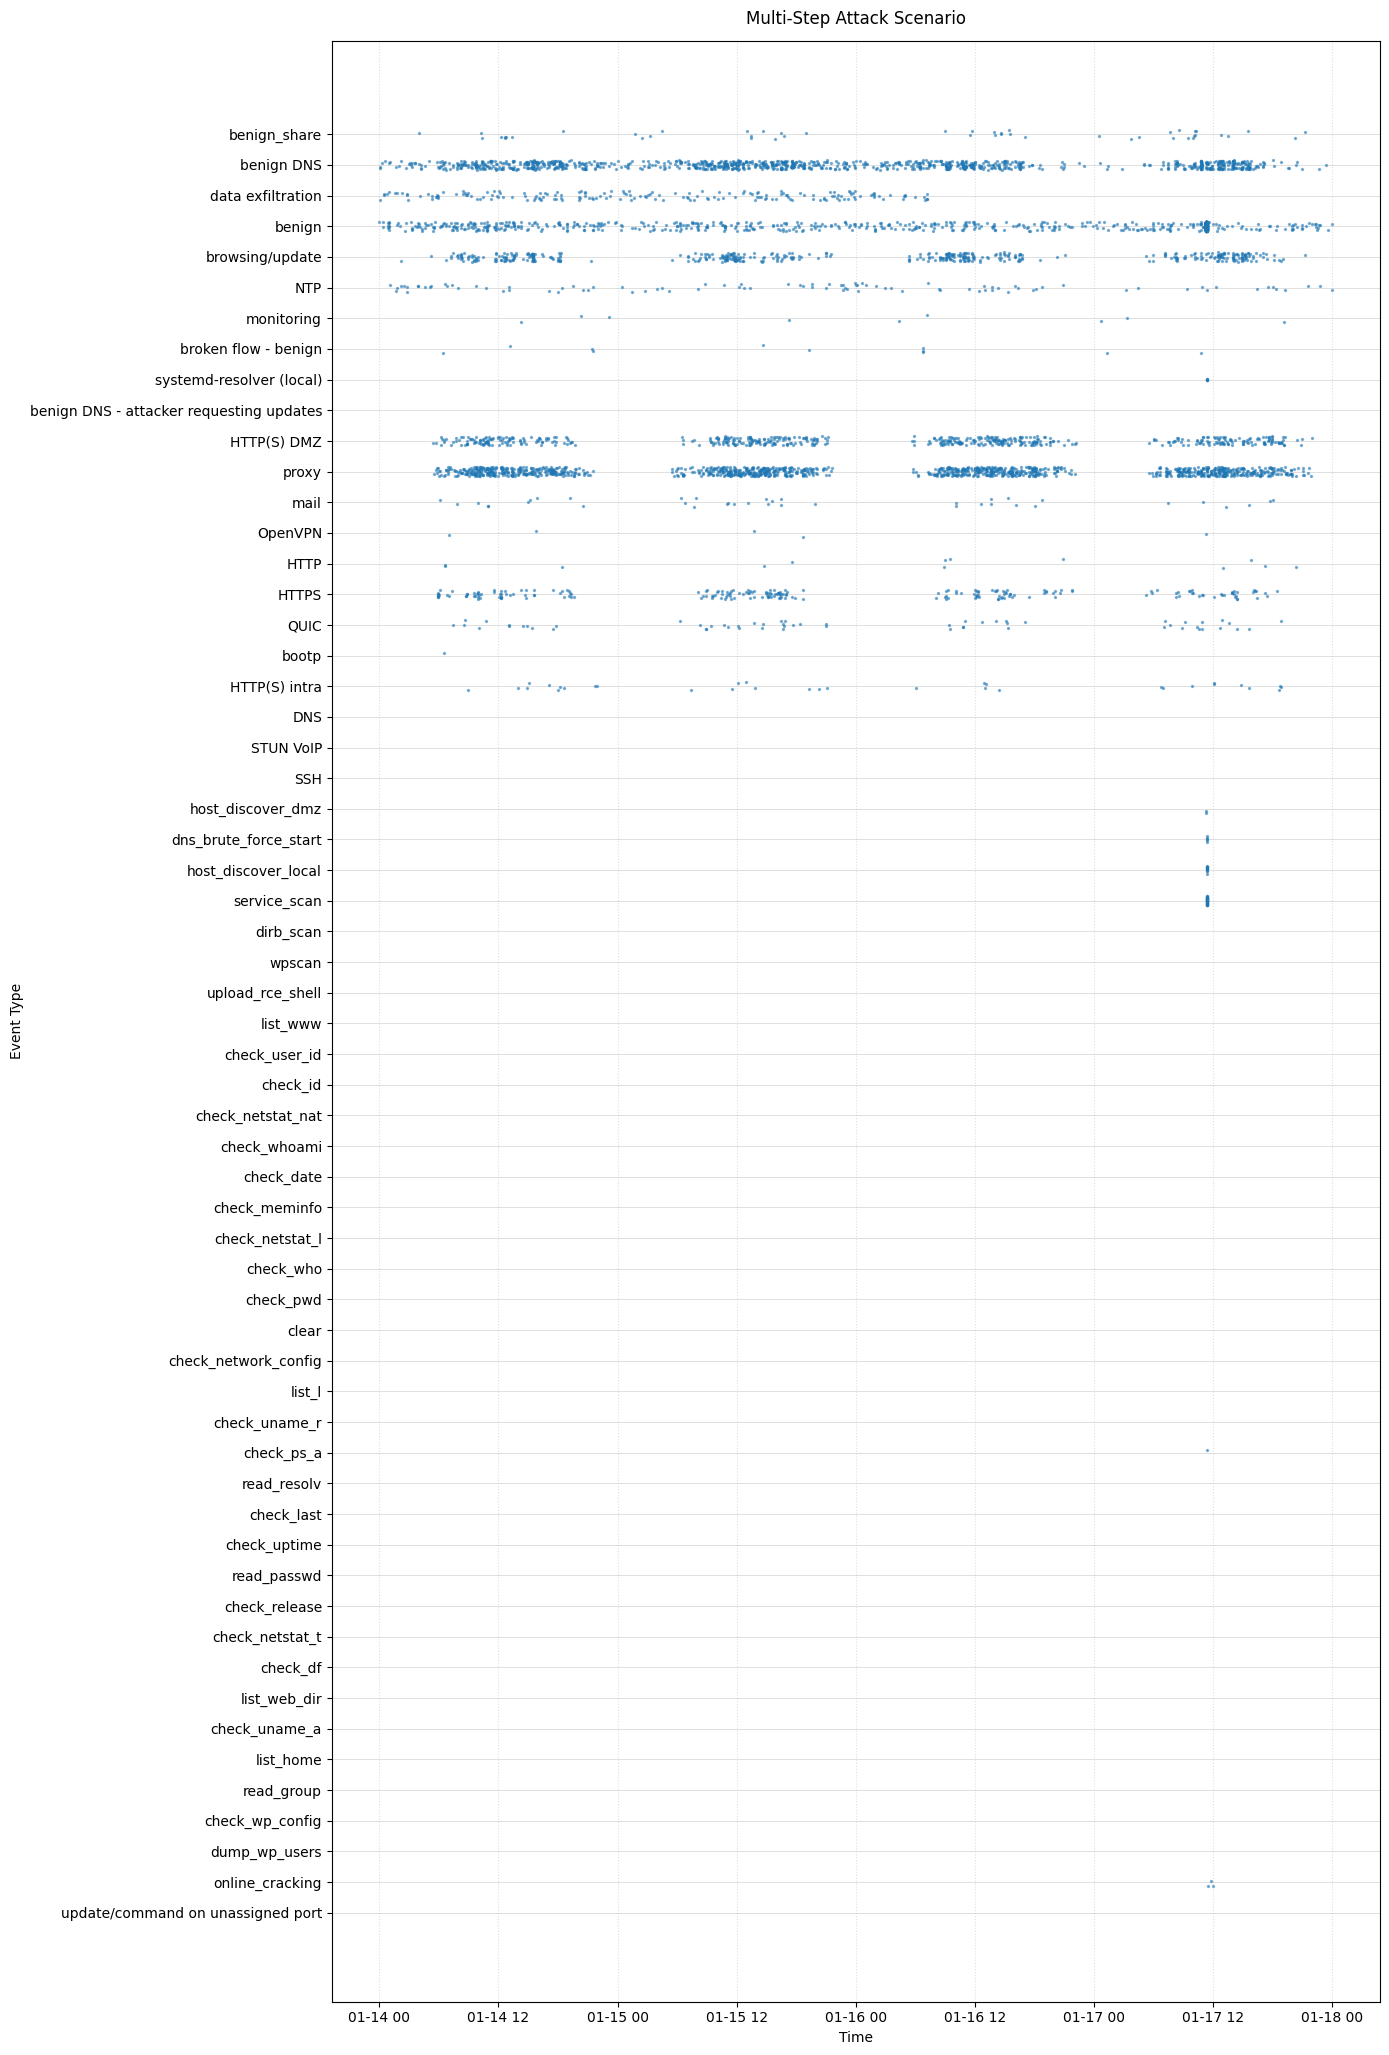

In [58]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df, order_sim)

### Plot Attack Period

In [59]:
print(f"Attack period - {scenario}:")
print(f"{attack_start} to {attack_end}")
    
df_attack_period = df[(df['start_time_dt'] >= attack_start) & (df['end_time_dt'] <= attack_end)]
print(f"Total attack flows in attack period: {len(df_attack_period)}")

Attack period - santos:
2022-01-17 11:15:00 to 2022-01-17 11:59:00
Total attack flows in attack period: 39783


In [60]:
phase_bounds_attack_period = (
    df_attack_period[df_attack_period['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack_period

,min,max
label,,
systemd-resolver (local),2022-01-17 11:15:00.073709965,2022-01-17 11:58:57.583493948
benign,2022-01-17 11:15:01.158945084,2022-01-17 11:58:28.891844034
NTP,2022-01-17 11:15:01.162257910,2022-01-17 11:58:57.645323038
benign_share,2022-01-17 11:15:02.065664053,2022-01-17 11:45:02.321163893
HTTP(S) DMZ,2022-01-17 11:15:06.202383041,2022-01-17 11:58:42.575423002
proxy,2022-01-17 11:15:06.209129095,2022-01-17 11:57:56.808773041
benign DNS,2022-01-17 11:15:09.443162918,2022-01-17 11:58:57.148287058
host_discover_dmz,2022-01-17 11:15:12.900707960,2022-01-17 11:20:35.309524059
monitoring,2022-01-17 11:17:04.318162918,2022-01-17 11:48:07.349020004


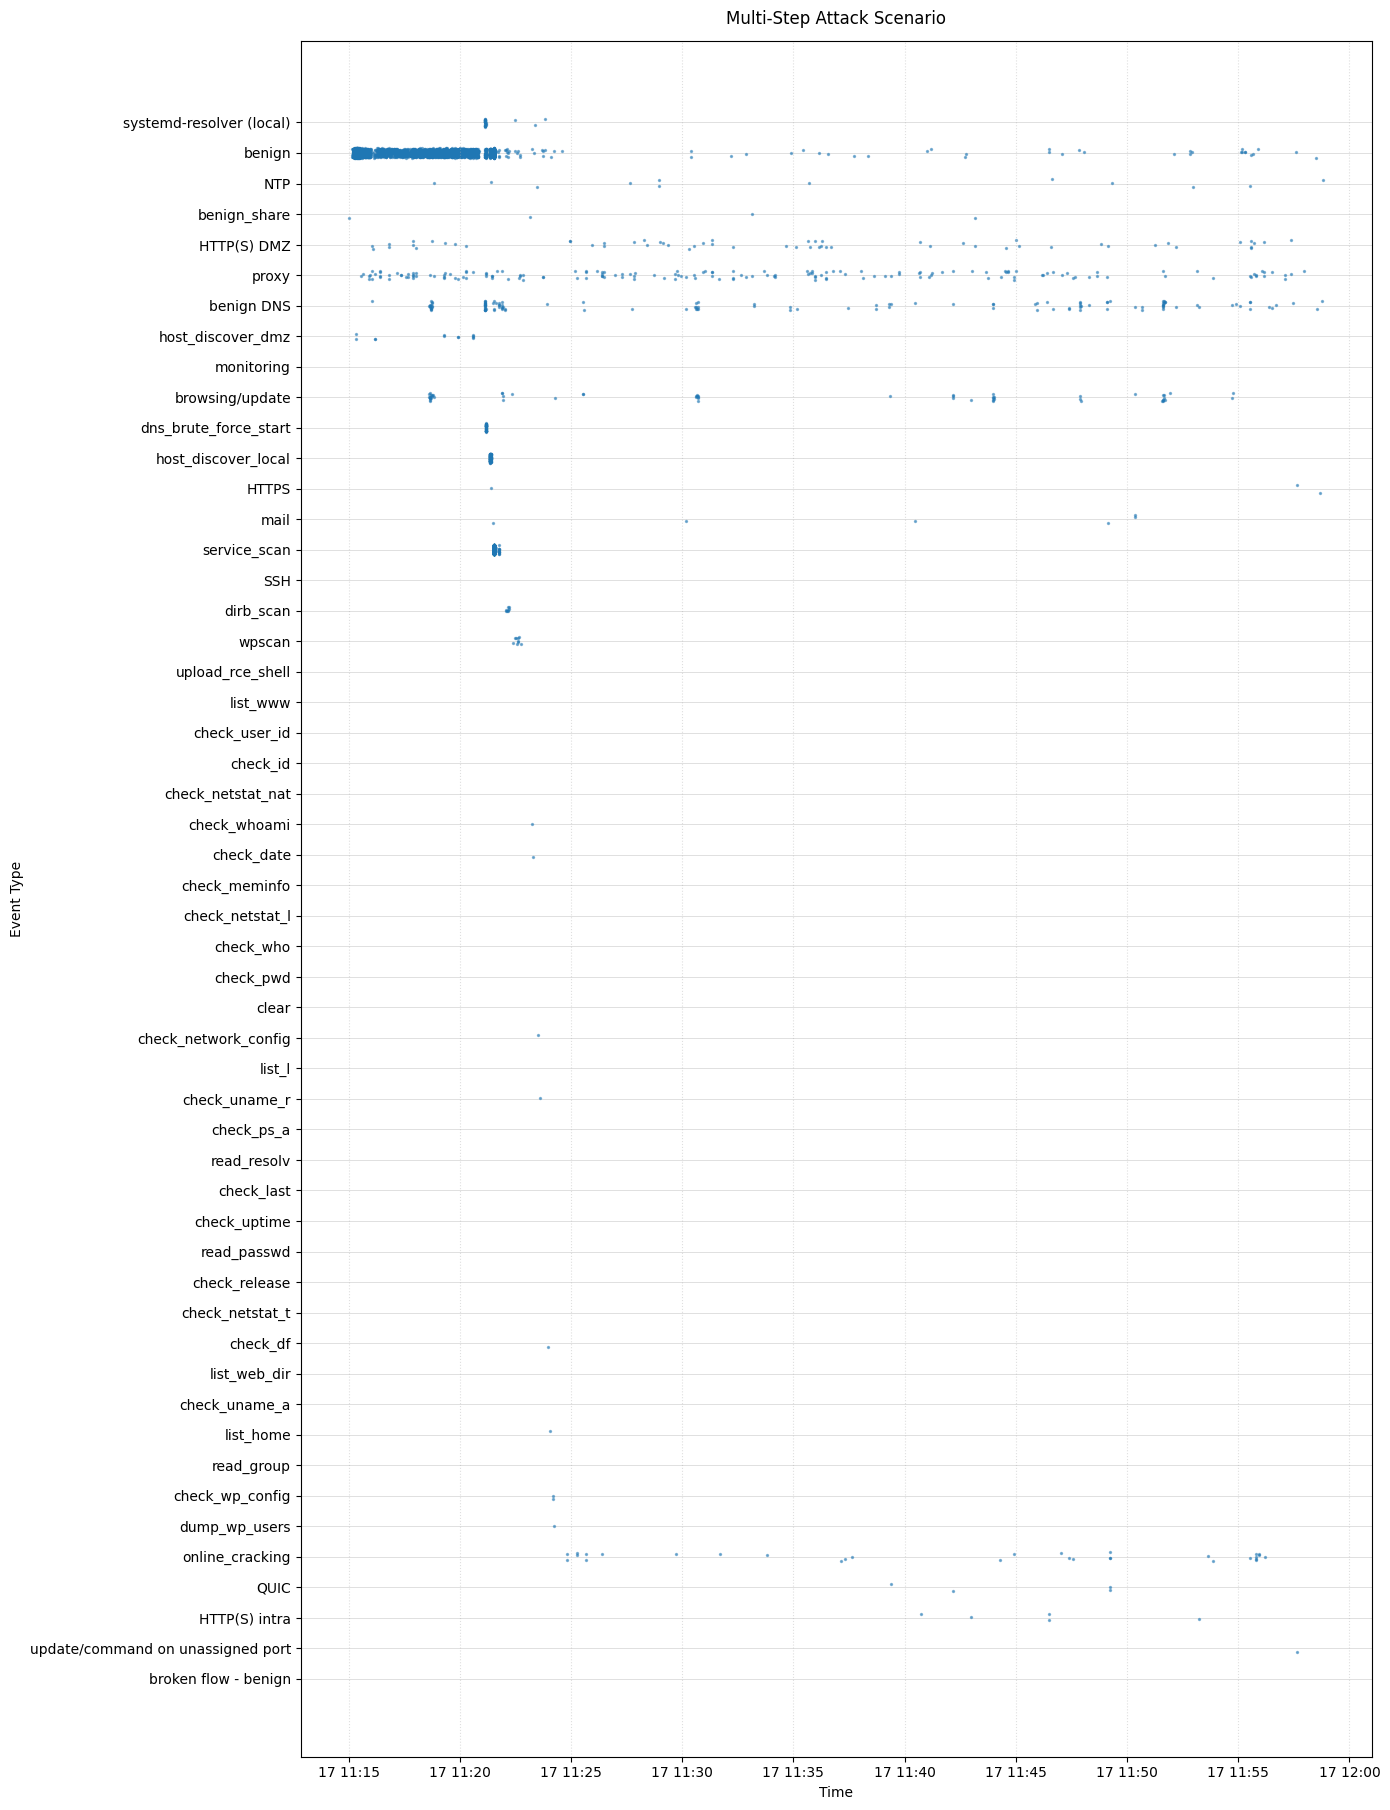

In [61]:
order_attack_period = phase_bounds_attack_period.index.tolist()
plot_event_raster(df_attack_period, order_attack_period)

### Label Multi-Step Attack

**Multi-Step Attack Phases**

Scans / reconnaissance:
- The first step of the attack chain then consists of several scans of the network.

Webshell upload / exploitation:
- Attacker exploits the vulnerable plugin which allows him to upload a PHP webshell as a backdoor.
- The attacker proceeds to execute several commands to gather information about the host.

Password cracking: 
- The attacker then attempts to crack one of the hashed passwords using a list of common passwords.

Privilege escalation: 
- Subsequently after obtaining the password, the attacker uploads a fully interactive reverse shell and misuses the compromised user account to escalate their privileges to root level. 

Remote command execution: 
- The attacker then executes several commands of which some require root privileges, such as reading out the shadow file.

Data exfiltration:
- As a final step of the attack kill chain, the attacker runs the DNSteal tool that exfiltrates sensitive data from the file share located in the intranet zone.
- Important note: The authors decided to separate this step from the remaining attack vectors and instead start the exfiltration tool already at the beginning of the simulation.

Missing steps in Zeek flow data:
- Privilege escalation and remote command execution are not present in the Zeek flow data, which is likely due to the fact that these steps do not involve any network communication.

In [62]:
# From netflows labeling file:
benign_tcp_complete_labels = ["browsing/update", "benign_share", "mail", "monitoring", "HTTP(S) intra", "HTTP(S) DMZ", "SSH", "proxy", "HTTPS", "HTTP", "DNS", "update/command on unassigned port"]
benign_tcp_nocomplete_labels = ["broken flow - benign"]
benign_udp_labels = ["NTP", "bootp", "OpenVPN", "STUN VoIP", "NetBIOS", "QUIC", "mDNS", "mDNSv6", "GoogleDNS", "systemd-resolver (local)", "benign DNS", "benign DNS - attacker requesting updates"]

benign_labels = benign_tcp_complete_labels + benign_tcp_nocomplete_labels + benign_udp_labels + ["benign"]

In [63]:
# From netflows labeling file:

# foothold_labels = ["vpn_connect", "traceroute", "host_discover_local", "host_discover_dmz", "dns_brute_force_start", "service_scan", "wpscan", "dirb_scan", "upload_rce_shell", "host_recon_commands", "online_cracking", "run_cracking"]
# pwd_cracking_labels = ["Password cracking"]
# check_labels = ["check_df", "read_passwd", "check_id", "check_last", "read_resolv", "dump_wp_users", "check_who", "check_wp_config", "clear", "list_l", "check_netstat_l", "check_user_id", "check_uptime", "check_netstat_t", "read_group", "list_web_dir", "check_uname_r", "check_ps_a", "check_uname_a", "check_pwd", "check_network_config", "check_whoami", "list_home", "list_www", "check_meminfo", "check_netstat_nat", "check_date", "check_release", "read_profile"]

exfil = ['data exfiltration']
recon = ['dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan']
exploit = ['upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile']
cracking = ['online_cracking']

msa_labels = recon + exploit + cracking + exfil

In [64]:
# Sanity check
observed_labels = set(df_sim["label"].unique())
print("All labels in dataset:\n", observed_labels)
print("Benign labels:\n", set(benign_labels))
print("Multi-step attack labels:\n", set(msa_labels))
print()
print("Number of unique labels in observed data:", len(observed_labels))
print("Total number of unique labels in true categories:", len(benign_labels) + len(msa_labels)) 

for observed_label in observed_labels:
    if observed_label not in benign_labels and observed_label not in msa_labels:
        print(f"Label '{observed_label}' is in the dataset but not categorized as benign, multi-step attack, or exfiltration")

# assert(all_labels.issubset(set(benign_labels) | set(msa_labels))), "Some labels in the dataset are not categorized as benign, multi-step attack, or exfiltration"
# assert(len(all_labels) <= len(benign_labels) + len(msa_labels)), "There are more unique labels in the dataset than the total number of labels defined in the categories"

All labels in dataset:
 {'list_www', 'bootp', 'check_uname_r', 'host_discover_dmz', 'check_last', 'browsing/update', 'read_group', 'check_id', 'NTP', 'list_web_dir', 'HTTP(S) DMZ', 'online_cracking', 'benign DNS', 'check_ps_a', 'systemd-resolver (local)', 'check_release', 'QUIC', 'broken flow - benign', 'check_pwd', 'dirb_scan', 'HTTPS', 'mail', 'check_netstat_l', 'upload_rce_shell', 'benign_share', 'check_uname_a', 'check_netstat_nat', 'check_wp_config', 'dump_wp_users', 'service_scan', 'dns_brute_force_start', 'monitoring', 'check_user_id', 'proxy', 'OpenVPN', 'SSH', 'list_home', 'check_whoami', 'read_passwd', 'check_network_config', 'DNS', 'benign DNS - attacker requesting updates', 'data exfiltration', 'check_netstat_t', 'wpscan', 'check_who', 'HTTP', 'check_date', 'list_l', 'host_discover_local', 'STUN VoIP', 'clear', 'check_uptime', 'read_resolv', 'check_df', 'update/command on unassigned port', 'HTTP(S) intra', 'check_meminfo', 'benign'}
Benign labels:
 {'bootp', 'browsing/updat

In [65]:
df_msa = df_attack_period[df_attack_period["label"].isin(msa_labels)]
print(f"Total multi-step attack flows in true attack period: {len(df_msa)}")

Total multi-step attack flows in true attack period: 5924


In [66]:
obs_msa_labels, obs_msa_label_counts = \
    get_observed_labels_and_counts(df_msa)

for label in obs_msa_labels:
    print(f"Observed number of flows with msa label '{label}': {obs_msa_label_counts[label]}")
    print(f"Number of flows with msa label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with msa label 'host_discover_dmz': 115
Number of flows with msa label 'host_discover_dmz' in netflows: 115

Observed number of flows with msa label 'read_group': 2
Number of flows with msa label 'read_group' in netflows: 2

Observed number of flows with msa label 'online_cracking': 228
Number of flows with msa label 'online_cracking' in netflows: 228

Observed number of flows with msa label 'check_ps_a': 2
Number of flows with msa label 'check_ps_a' in netflows: 2

Observed number of flows with msa label 'check_release': 2
Number of flows with msa label 'check_release' in netflows: 2

Observed number of flows with msa label 'dirb_scan': 90
Number of flows with msa label 'dirb_scan' in netflows: 90

Observed number of flows with msa label 'upload_rce_shell': 2
Number of flows with msa label 'upload_rce_shell' in netflows: 2

Observed number of flows with msa label 'check_wp_config': 2
Number of flows with msa label 'check_wp_config' in netflows: 2

Observed num

In [67]:
phase_bounds_msa = (
    df_msa
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_msa

,min,max
label,,
host_discover_dmz,2022-01-17 11:15:12.900707960,2022-01-17 11:20:35.309524059
dns_brute_force_start,2022-01-17 11:21:09.514715910,2022-01-17 11:21:10.257448911
host_discover_local,2022-01-17 11:21:21.226320028,2022-01-17 11:21:23.334497929
service_scan,2022-01-17 11:21:32.394479990,2022-01-17 11:21:46.958153009
dirb_scan,2022-01-17 11:22:02.550590038,2022-01-17 11:22:13.053563118
wpscan,2022-01-17 11:22:23.349515915,2022-01-17 11:22:44.917221069
upload_rce_shell,2022-01-17 11:22:57.162303925,2022-01-17 11:22:57.163022995
check_user_id,2022-01-17 11:23:03.510241984,2022-01-17 11:23:03.510807990
check_date,2022-01-17 11:23:16.512259959,2022-01-17 11:23:16.512897014


In [68]:
out_dir = Path(f"../reports/{dataset}/multi_step_attack_scenarios")
out_dir.mkdir(parents=True, exist_ok=True)
file_path = out_dir / f"{dataset}_{scenario}_msa_scenario.png"

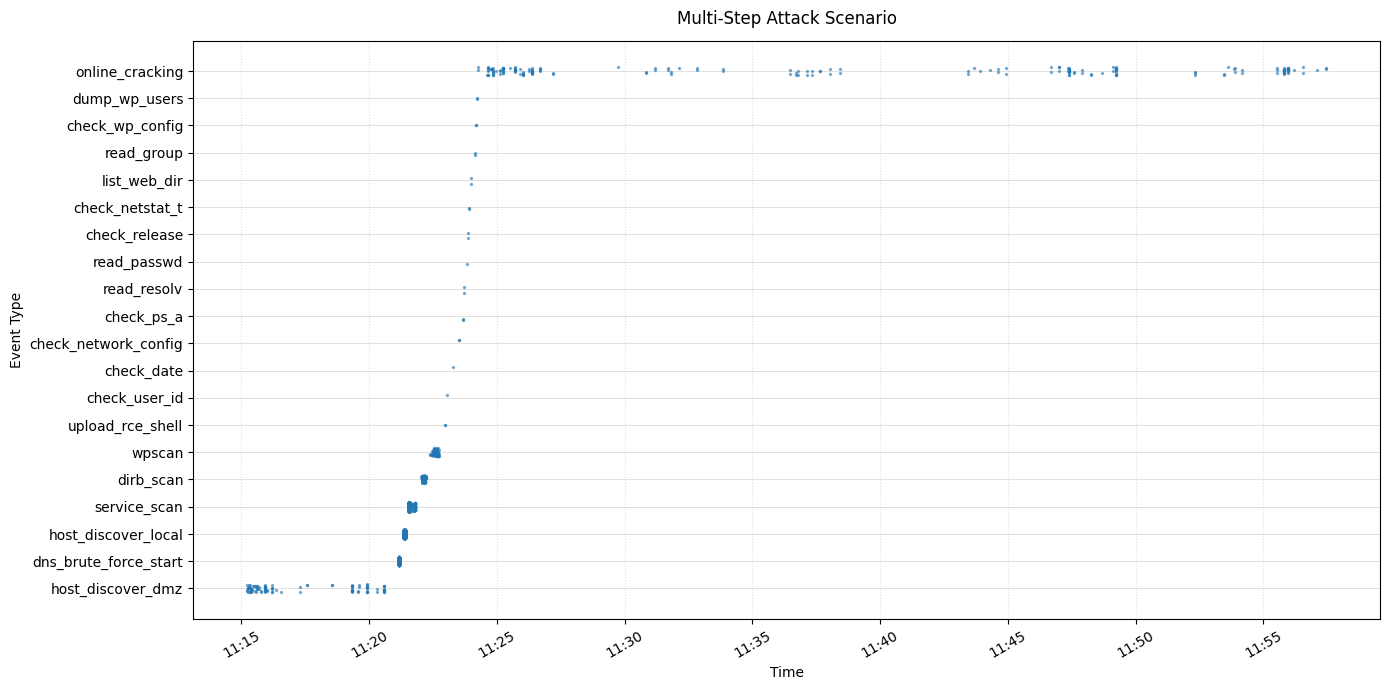

In [69]:
order_msa = phase_bounds_msa.index.tolist()
plot_event_raster(df_attack=df_msa, order=order_msa, attack=True, invert_y=False, save_plot=True, file_path = file_path)

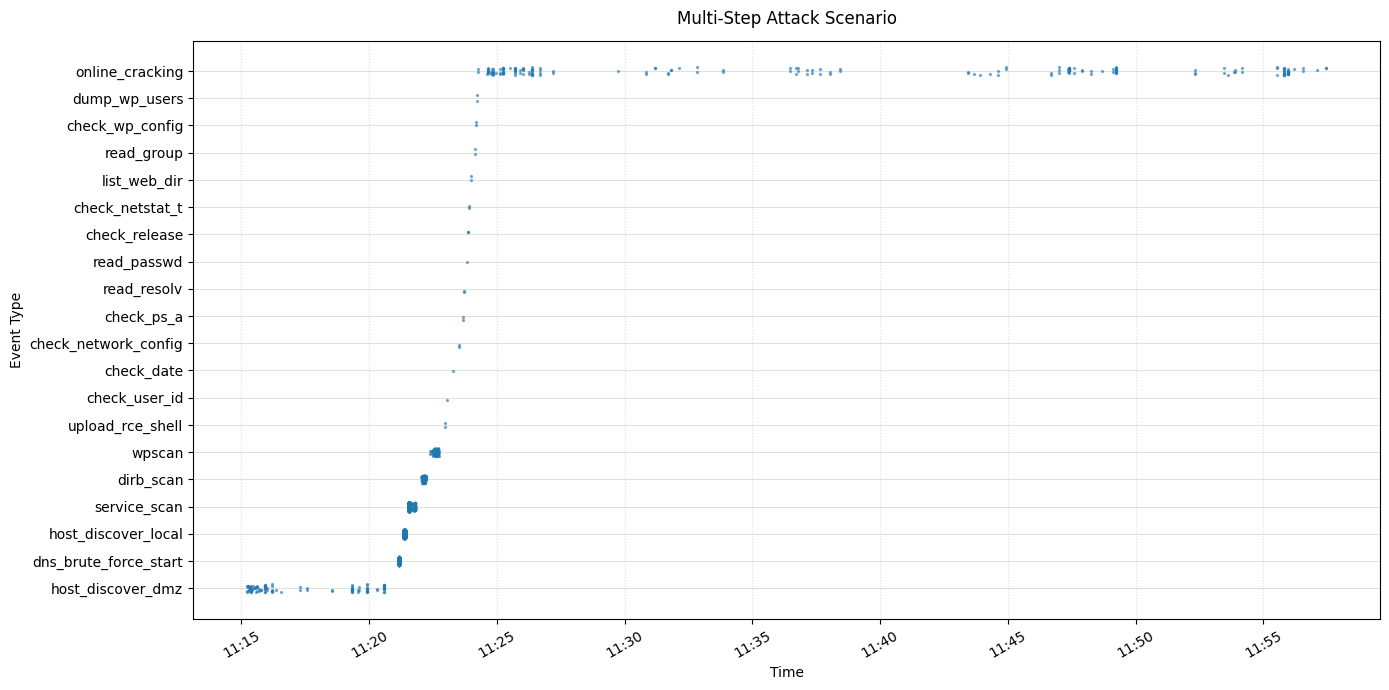

In [70]:
phase_bounds_msa_no_exfil = (
    df_msa[df_msa['label'] != 'data exfiltration']
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

order_msa_no_exfil = phase_bounds_msa_no_exfil.index.tolist()
plot_event_raster(df_attack=df_msa, order=order_msa_no_exfil, attack=True, invert_y=False)

In [71]:
def label_phase(label):
    if label in recon:
        return 1
    elif label in exploit:
        return 2
    elif label in cracking:
        return 3
    elif label in exfil:
        return 4
    else: # benign or unknown
        return 0
    
# Reload the dataset to ensure we have the original labels before adding the phase column
df = pd.read_csv(f"{data_dir}/all_flows_labeled_sim.csv")

df["phase"] = df["label"].apply(label_phase)
label_counts = df["phase"].value_counts()
print("Phase distribution:")
print(label_counts)
df.to_csv(f"{data_dir}/all_flows_labeled.csv", index=False)

Phase distribution:
phase
0    333964
4     12861
1      5670
3       228
2        26
Name: count, dtype: int64


## Dataset Statistics

In [72]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

In [73]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [74]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

Label Distribution for All Sensors:
label
service_scan             4056
host_discover_local      1000
dns_brute_force_start     325
online_cracking           228
host_discover_dmz         115
dirb_scan                  90
wpscan                     84
upload_rce_shell            2
check_date                  2
check_network_config        2
check_ps_a                  2
check_user_id               2
read_resolv                 2
read_passwd                 2
check_netstat_t             2
check_release               2
list_web_dir                2
read_group                  2
check_wp_config             2
dump_wp_users               2
Name: count, dtype: int64



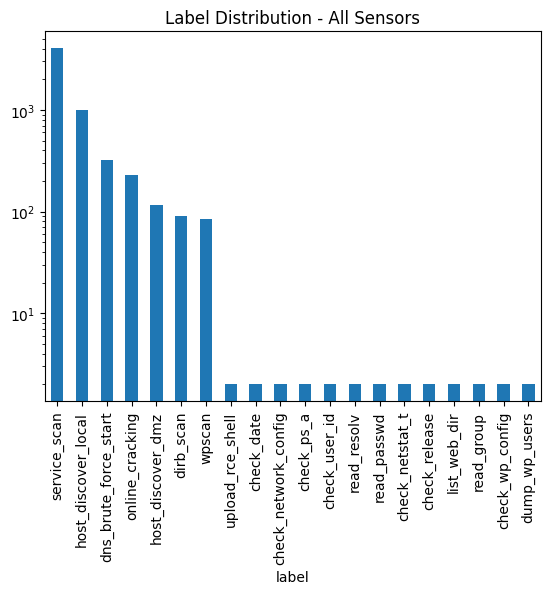

In [75]:
label_stats(df_msa, "All Sensors")

In [76]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 352749
Unique Source IPs: 130
Unique Destination IPs: 12029
Unique Source Ports: 47841
Unique Destination Ports: 1084


{'total_flows': 352749,
 'unique_src_ips': 130,
 'unique_dst_ips': 12029,
 'unique_src_ports': 47841,
 'unique_dst_ports': 1084}

In [77]:
# Attack flows stats
dataset_stats(df_msa)

Total Flows: 5924
Unique Source IPs: 5
Unique Destination IPs: 265
Unique Source Ports: 3893
Unique Destination Ports: 592


{'total_flows': 5924,
 'unique_src_ips': 5,
 'unique_dst_ips': 265,
 'unique_src_ports': 3893,
 'unique_dst_ports': 592}

In [78]:
dataset_stats_detailed(df_msa)

Total Flows: 5924

 --- IP distribution ---

Source IPs (5):
src_ip
172.21.128.119     5322
10.229.2.216        596
10.229.0.4            3
10.229.1.118          2
192.168.104.155       1
Name: count, dtype: int64

Destination IPs (265):
dst_ip
192.168.104.155    1101
172.21.131.50       896
172.21.128.54       870
192.168.104.218     841
10.229.255.254      596
                   ... 
192.168.104.95        1
192.168.104.141       1
192.168.104.198       1
192.168.104.98        1
192.168.104.81        1
Name: count, Length: 265, dtype: int64

 --- Port distribution ---
Source Ports (3893):
sport
60056    6
48932    6
46186    6
41554    6
35788    6
        ..
56988    1
35870    1
48046    1
60094    1
50052    1
Name: count, Length: 3893, dtype: int64

Destination Ports (592):
dport
443     1068
80       608
587       26
993       14
139       14
        ... 
146        5
8873       5
5633       5
800        5
1088       5
Name: count, Length: 592, dtype: int64


(src_ip
 172.21.128.119     5322
 10.229.2.216        596
 10.229.0.4            3
 10.229.1.118          2
 192.168.104.155       1
 Name: count, dtype: int64,
 dst_ip
 192.168.104.155    1101
 172.21.131.50       896
 172.21.128.54       870
 192.168.104.218     841
 10.229.255.254      596
                    ... 
 192.168.104.95        1
 192.168.104.141       1
 192.168.104.198       1
 192.168.104.98        1
 192.168.104.81        1
 Name: count, Length: 265, dtype: int64,
 sport
 60056    6
 48932    6
 46186    6
 41554    6
 35788    6
         ..
 56988    1
 35870    1
 48046    1
 60094    1
 50052    1
 Name: count, Length: 3893, dtype: int64,
 dport
 443     1068
 80       608
 587       26
 993       14
 139       14
         ... 
 146        5
 8873       5
 5633       5
 800        5
 1088       5
 Name: count, Length: 592, dtype: int64)